In [ ]:
# -*- coding: utf-8 -*-
"""Lab-6-SVM.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1Az59g2DkfeHUafr25_b2GR321r7kn0kN
"""

import pandas as pd
from sklearn.datasets import load_digits
digits = load_digits()

digits.target

dir(digits)

digits.target_names

df = pd.DataFrame(digits.data,digits.target)
df.head()

df['target'] = digits.target
df.head(20)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('target',axis='columns'), df.target, test_size=0.3)

"""Using RBF kernel"""

from sklearn.svm import SVC
rbf_model = SVC(kernel='rbf')

len(X_train)

len(X_test)

rbf_model.fit(X_train, y_train)

rbf_model.score(X_test,y_test)

"""Using Linear kernel"""

linear_model = SVC(kernel='linear')
linear_model.fit(X_train,y_train)

linear_model.score(X_test,y_test)

0.9796296296296296

Accuracy (Linear Kernel): 1.0
Confusion Matrix (Linear Kernel):
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


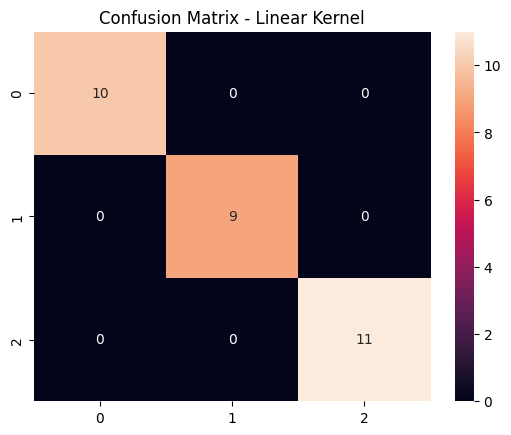

Accuracy (RBF Kernel): 1.0
Confusion Matrix (RBF Kernel):
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


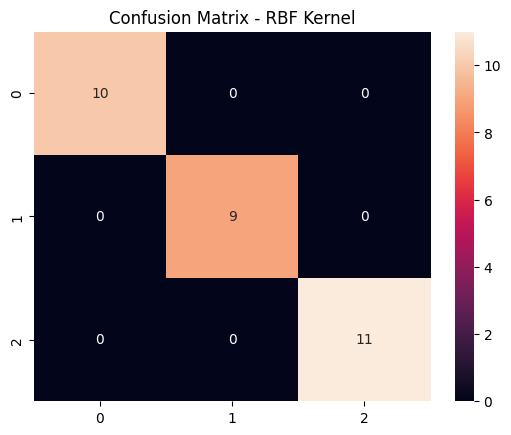

In [6]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load Excel dataset
data = pd.read_excel("iris.xlsx")

# Features and Target
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Split dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# -------- Linear Kernel --------
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

y_pred_linear = svm_linear.predict(X_test)

print("Accuracy (Linear Kernel):", accuracy_score(y_test, y_pred_linear))

cm_linear = confusion_matrix(y_test, y_pred_linear)
print("Confusion Matrix (Linear Kernel):")
print(cm_linear)

sns.heatmap(cm_linear, annot=True)
plt.title("Confusion Matrix - Linear Kernel")
plt.show()


# -------- RBF Kernel --------
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)

print("Accuracy (RBF Kernel):", accuracy_score(y_test, y_pred_rbf))

cm_rbf = confusion_matrix(y_test, y_pred_rbf)
print("Confusion Matrix (RBF Kernel):")
print(cm_rbf)

sns.heatmap(cm_rbf, annot=True)
plt.title("Confusion Matrix - RBF Kernel")
plt.show()

Accuracy: 0.8545
Confusion Matrix:
[[140   1   0   0   0   0   2   0   0   2   0   0   0   0   0   0   0   1
    1   0   0   1   0   0   1   0]
 [  1 133   0   3   0   0   0   5   0   0   1   0   0   1   0   1   0   6
    1   0   0   1   0   0   0   0]
 [  0   0 117   0   1   0   4   2   0   0   6   1   0   0   3   0   0   0
    1   0   2   0   0   0   0   0]
 [  0   6   0 141   0   0   0   2   0   1   2   0   0   1   1   0   0   0
    0   2   0   0   0   0   0   0]
 [  0   1   2   0 127   0   4   0   0   0   1   1   0   0   0   0   1   1
    2   1   0   0   0   0   0   0]
 [  0   0   0   0   3 127   0   1   2   1   0   0   0   0   0   1   0   0
    2   3   0   0   0   0   0   0]
 [  0   1   8   2   0   0 129   2   0   1   3   0   0   0   0   0   7   1
    2   0   0   2   2   0   0   0]
 [  1   4   1  10   1   2   0  85   0   3   6   0   0   2  10   1   2  12
    0   0   2   0   0   1   1   0]
 [  0   0   0   3   0   2   0   0 127   6   0   2   0   0   0   0   1   0
    1   0   0   0  

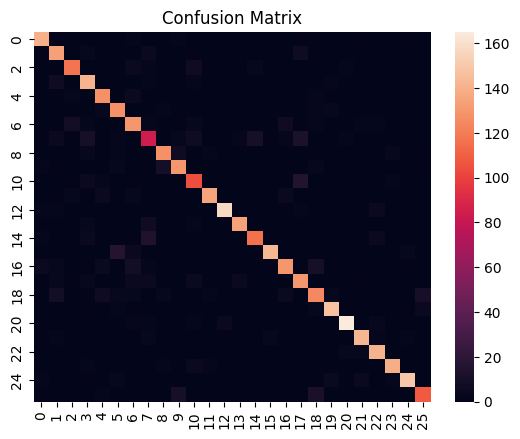

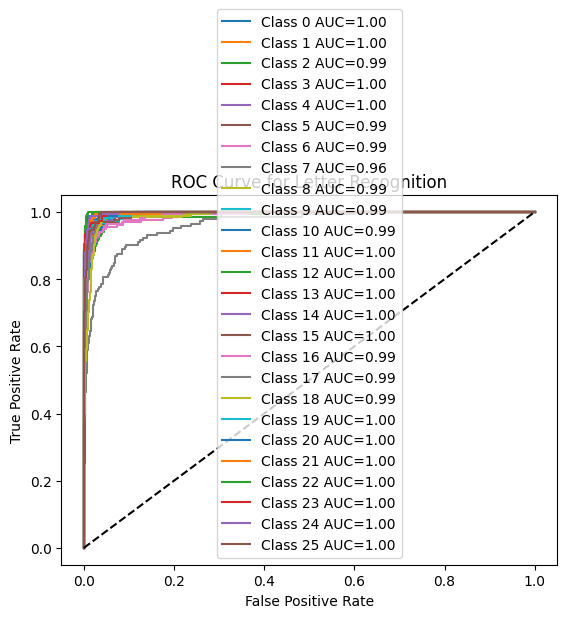

In [9]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = pd.read_excel("letter-recognition.xlsx")

# Target column = first column (letters)
y = data.iloc[:, 0]

# Features = remaining columns
X = data.iloc[:, 1:]

# Convert letters (A-Z) into numbers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42)

# Train SVM
svm = SVC(kernel='linear', probability=True)
svm.fit(X_train, y_train)

# Predictions
y_pred = svm.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

sns.heatmap(cm)
plt.title("Confusion Matrix")
plt.show()

# ----- ROC Curve -----

# Binarize labels
classes = np.unique(y_encoded)
y_test_bin = label_binarize(y_test, classes=classes)

# Probability scores
y_score = svm.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
for i in range(len(classes)):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} AUC={roc_auc[i]:.2f}")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Letter Recognition")
plt.legend()
plt.show()